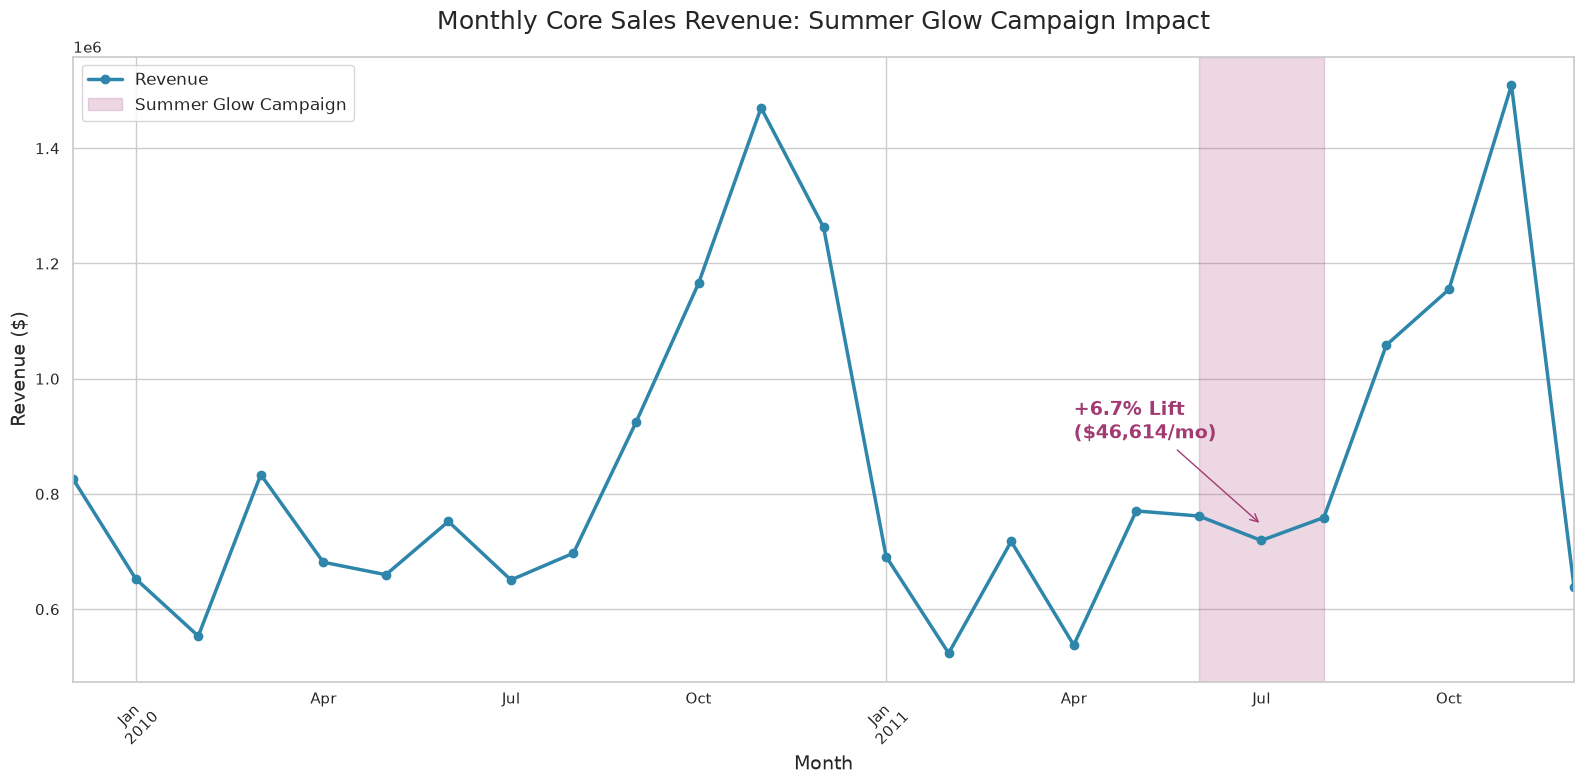

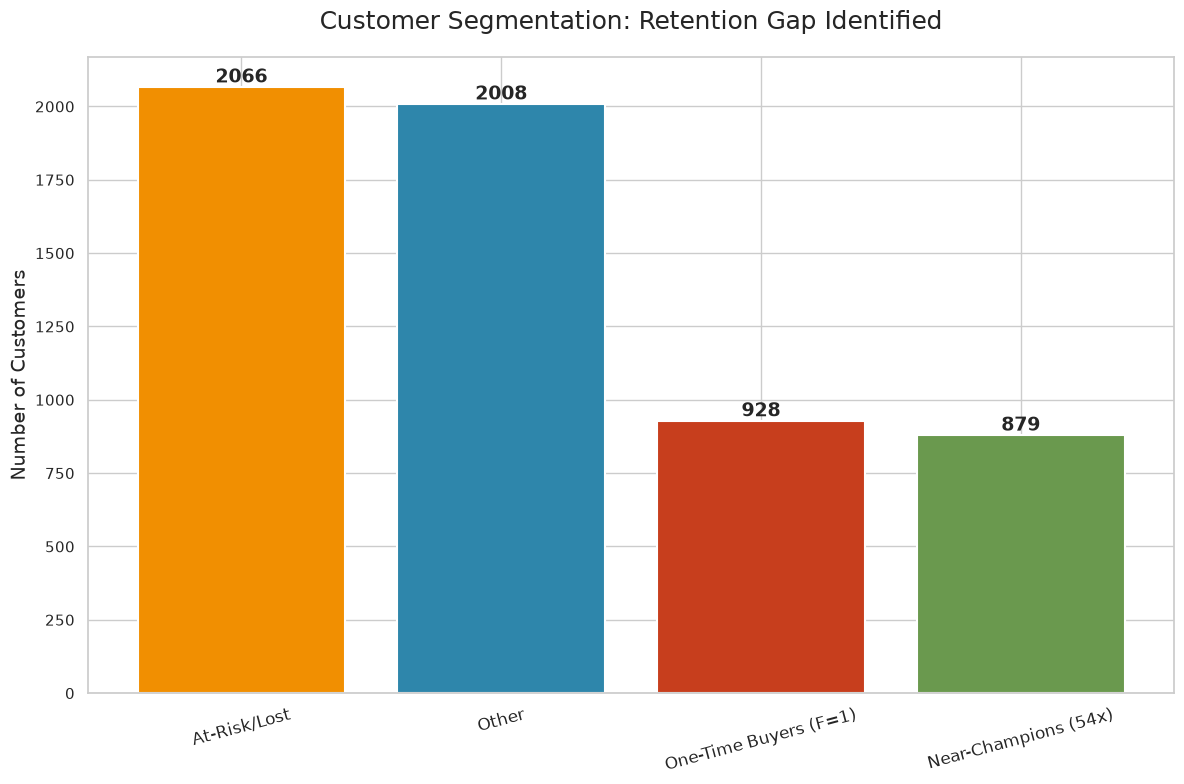

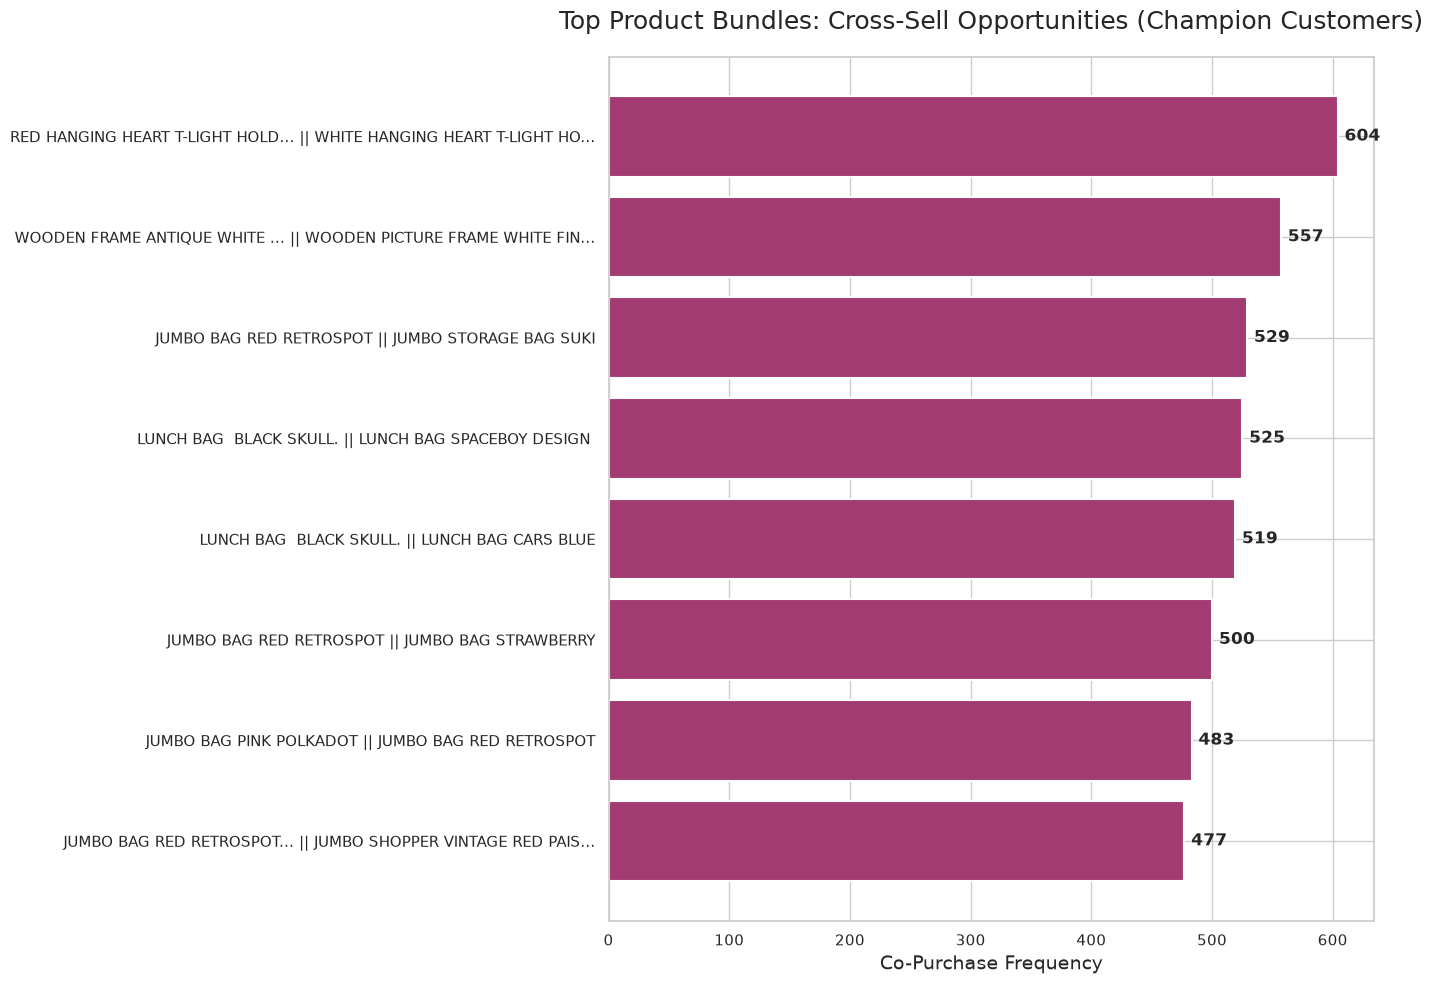

/tmp/ipykernel_77262/2647584191.py:141: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_77262/2647584191.py:142: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('chart4_campaign_summary.png', dpi=150, bbox_inches='tight')
/home/sam/projects/ShopSmart/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


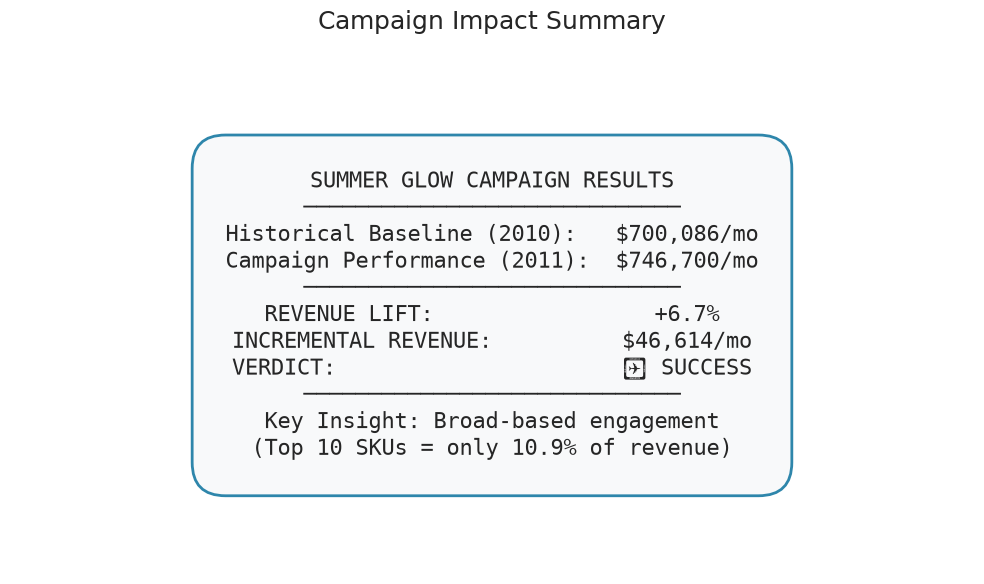

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# === SETUP: LOAD CLEANED DATA ===
df = pd.read_csv('/home/sam/projects/ShopSmart/Data/online_retail_II.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].fillna('GUEST').astype(str)
valid_df = df[~df['Invoice'].str.startswith('C', na=False)].copy()
valid_df['Revenue'] = valid_df['Quantity'] * valid_df['Price']
valid_df['Transaction_Type'] = 'Sale'
valid_df.loc[valid_df['Revenue'] < 0, 'Transaction_Type'] = 'Adjustment'

# Set professional styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# === CHART 1: Monthly Revenue Trend with Campaign Highlight ===
monthly_sales = valid_df[valid_df['Transaction_Type']=='Sale'].groupby(
    pd.Grouper(key='InvoiceDate', freq='ME')
)['Revenue'].sum()

fig, ax = plt.subplots(figsize=(16, 8))
monthly_sales.plot(ax=ax, color='#2E86AB', linewidth=2.5, marker='o', markersize=6)

# Highlight Summer Glow period (Jun-Aug 2011)
ax.axvspan(datetime(2011,6,1), datetime(2011,8,31), 
           alpha=0.2, color='#A23B72', label='Summer Glow Campaign')

# Annotate key points
baseline_2010 = monthly_sales.loc['2010-06':'2010-08'].mean()
campaign_avg = monthly_sales.loc['2011-06':'2011-08'].mean()
ax.annotate(f'+6.7% Lift\n(${campaign_avg-baseline_2010:,.0f}/mo)', 
            xy=(datetime(2011,7,15), campaign_avg),
            xytext=(datetime(2011,4,1), campaign_avg + 150000),
            arrowprops=dict(arrowstyle='->', color='#A23B72'),
            fontsize=14, fontweight='bold', color='#A23B72')

ax.set_title('Monthly Core Sales Revenue: Summer Glow Campaign Impact', fontsize=18, pad=20)
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Revenue ($)', fontsize=14)
ax.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 2: RFM Segment Distribution ===
# Recreate RFM segments (using previously computed logic)
rfm_df = valid_df[(valid_df['Transaction_Type']=='Sale') & (valid_df['Customer ID'] != 'GUEST')].copy()
snapshot_date = rfm_df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = rfm_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

for col in ['Recency', 'Frequency', 'Monetary']:
    if col == 'Recency':
        base_labels = [5,4,3,2,1]
    else:
        base_labels = [1,2,3,4,5]
    _, bins = pd.qcut(rfm[col], q=5, retbins=True, duplicates='drop')
    n_bins = len(bins) - 1
    labels = base_labels[-n_bins:] if col=='Recency' else base_labels[:n_bins]
    rfm[f'{col}_Score'] = pd.qcut(rfm[col], q=5, labels=labels, duplicates='drop').astype(int)

rfm['Segment'] = 'Other'
rfm.loc[(rfm['Recency_Score']>=4) & (rfm['Frequency_Score']>=4), 'Segment'] = 'Near-Champions (54x)'
rfm.loc[(rfm['Frequency_Score']==1), 'Segment'] = 'One-Time Buyers (F=1)'
rfm.loc[(rfm['Recency_Score']<=2) & (rfm['Frequency_Score']<=2), 'Segment'] = 'At-Risk/Lost'

seg_counts = rfm['Segment'].value_counts()
colors = ['#F18F01', '#2E86AB', '#C73E1D', '#6A994E']

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(seg_counts.index, seg_counts.values, color=colors[:len(seg_counts)], edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%d', fontsize=14, fontweight='bold')
ax.set_title('Customer Segmentation: Retention Gap Identified', fontsize=18, pad=20)
ax.set_ylabel('Number of Customers', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('chart2_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 3: Top Product Bundles Among Champions ===
champions = rfm[rfm['Segment']=='Near-Champions (54x)']['Customer ID']
champ_txns = valid_df[(valid_df['Transaction_Type']=='Sale') & (valid_df['Customer ID'].isin(champions))]
co_purchases = champ_txns.groupby('Invoice')['Description'].apply(list).reset_index()

from itertools import combinations
pair_counts = {}
for _, row in co_purchases.iterrows():
    products = sorted(set(row['Description']))
    for pair in combinations(products, 2):
        pair_key = f"{pair[0][:30]}... || {pair[1][:30]}..." if max(len(p) for p in pair)>30 else f"{pair[0]} || {pair[1]}"
        pair_counts[pair_key] = pair_counts.get(pair_key, 0) + 1

top_bundles = pd.Series(pair_counts).nlargest(8)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(range(len(top_bundles)), top_bundles.values, color='#A23B72', edgecolor='white', linewidth=1.5)
ax.set_yticks(range(len(top_bundles)))
ax.set_yticklabels(top_bundles.index, fontsize=11)
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d', fontsize=12, fontweight='bold', padding=5)
ax.set_title('Top Product Bundles: Cross-Sell Opportunities (Champion Customers)', fontsize=18, pad=20)
ax.set_xlabel('Co-Purchase Frequency', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_product_bundles.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 4: Campaign Impact Summary Card ===
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

card_text = (
    "SUMMER GLOW CAMPAIGN RESULTS\n"
    "─────────────────────────────\n"
    f"Historical Baseline (2010):   ${baseline_2010:,.0f}/mo\n"
    f"Campaign Performance (2011):  ${campaign_avg:,.0f}/mo\n"
    "─────────────────────────────\n"
    f"REVENUE LIFT:                 +6.7%\n"
    f"INCREMENTAL REVENUE:          ${campaign_avg-baseline_2010:,.0f}/mo\n"
    "VERDICT:                      ✅ SUCCESS\n"
    "─────────────────────────────\n"
    "Key Insight: Broad-based engagement\n"
    "(Top 10 SKUs = only 10.9% of revenue)"
)

ax.text(0.5, 0.5, card_text, transform=ax.transAxes, fontsize=16,
        verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace', bbox=dict(boxstyle='round,pad=1.5', 
                                          facecolor='#F8F9FA', 
                                          edgecolor='#2E86AB', linewidth=2))

plt.title('Campaign Impact Summary', fontsize=18, pad=20)
plt.tight_layout()
plt.savefig('chart4_campaign_summary.png', dpi=150, bbox_inches='tight')
plt.show()